# AAPL Stock Market Analysis (2020–2025)

Exploratory data analysis of Apple Inc. (AAPL) stock using Python (pandas, matplotlib).
Covers closing price trends, daily/monthly returns, volatility, and moving averages over a 5-year period.

In [1]:
!pip install yfinance
import yfinance as yf

# download 5 years of Apple stock data
df = yf.download("AAPL", start="2020-01-01", end="2025-01-01")

df.head()

/tmp/ipykernel_7646/2666934119.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333862,72.394070,71.091169,71.344039,135480400
2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200
2020-01-07,71.861862,72.466345,71.642704,72.211064,108872000
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200


In [2]:
# basic info
df.info()

# summary statistics
df.describe()

# check missing values
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1258 non-null   float64
 1   (High, AAPL)    1258 non-null   float64
 2   (Low, AAPL)     1258 non-null   float64
 3   (Open, AAPL)    1258 non-null   float64
 4   (Volume, AAPL)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


,,0
Price,Ticker,
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


No missing values across the full 5-year period — the dataset is clean and continuous, so no imputation or cleaning was required before analysis.

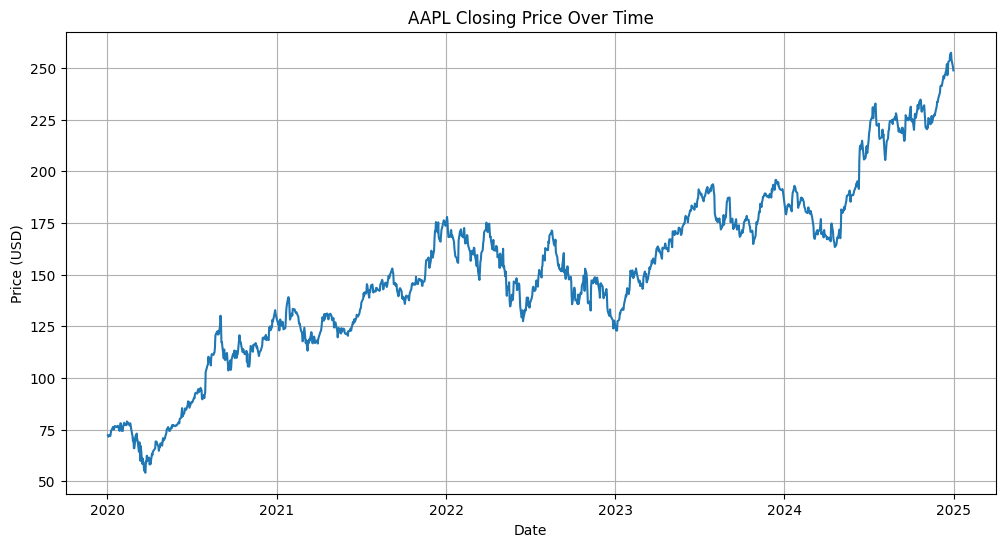

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['Close'])
plt.title("AAPL Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.show()

In [4]:
df['Daily Return'] = df['Close'].pct_change()
df['Daily Return'].head()

,Daily Return
Date,
2020-01-02,NaN
2020-01-03,-0.009722
2020-01-06,0.007968
2020-01-07,-0.004703
2020-01-08,0.016086


Daily volatility (std dev): 0.0200 (2.00%)
Annualized volatility: 0.3168 (31.68%)


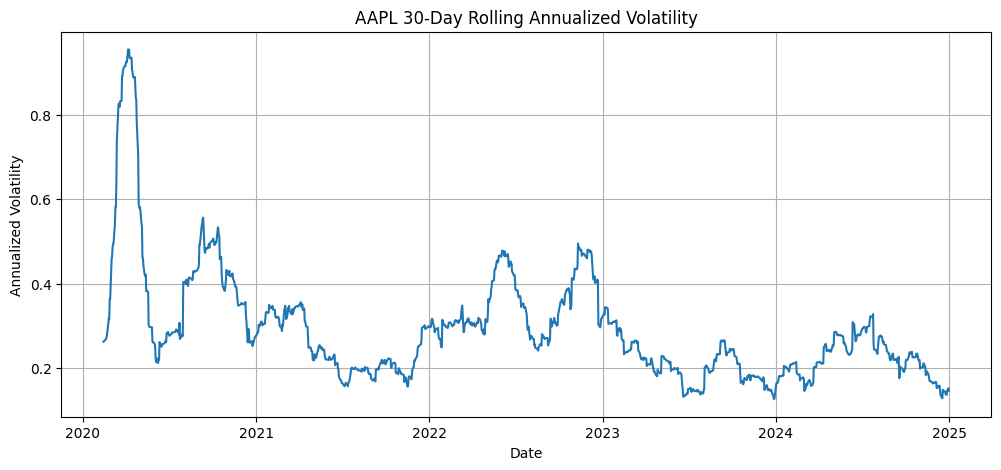

In [5]:
# Volatility analysis
daily_vol = df['Daily Return'].std()
annualized_vol = daily_vol * (252 ** 0.5)  # 252 trading days/year

print(f"Daily volatility (std dev): {daily_vol:.4f} ({daily_vol*100:.2f}%)")
print(f"Annualized volatility: {annualized_vol:.4f} ({annualized_vol*100:.2f}%)")

# Rolling 30-day volatility to see how it changes over time
df['Rolling_Volatility_30'] = df['Daily Return'].rolling(window=30).std() * (252 ** 0.5)

plt.figure(figsize=(12,5))
plt.plot(df['Rolling_Volatility_30'])
plt.title("AAPL 30-Day Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.grid(True)
plt.show()

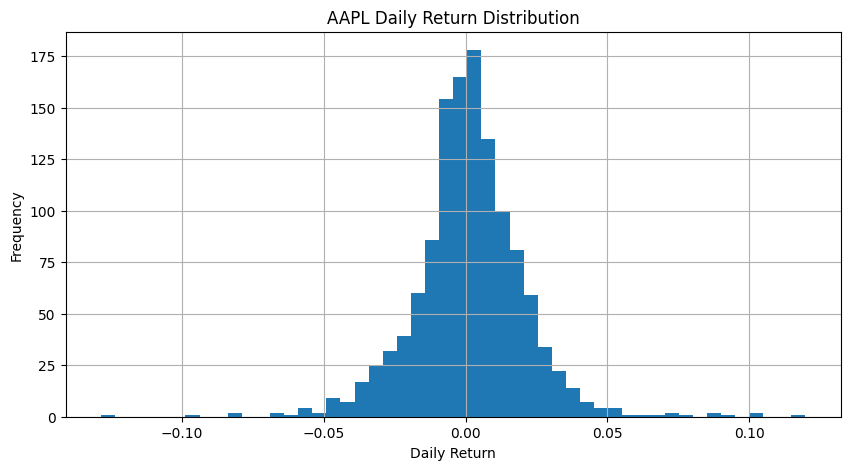

In [6]:
plt.figure(figsize=(10,5))
plt.hist(df['Daily Return'].dropna(), bins=50)
plt.title("AAPL Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

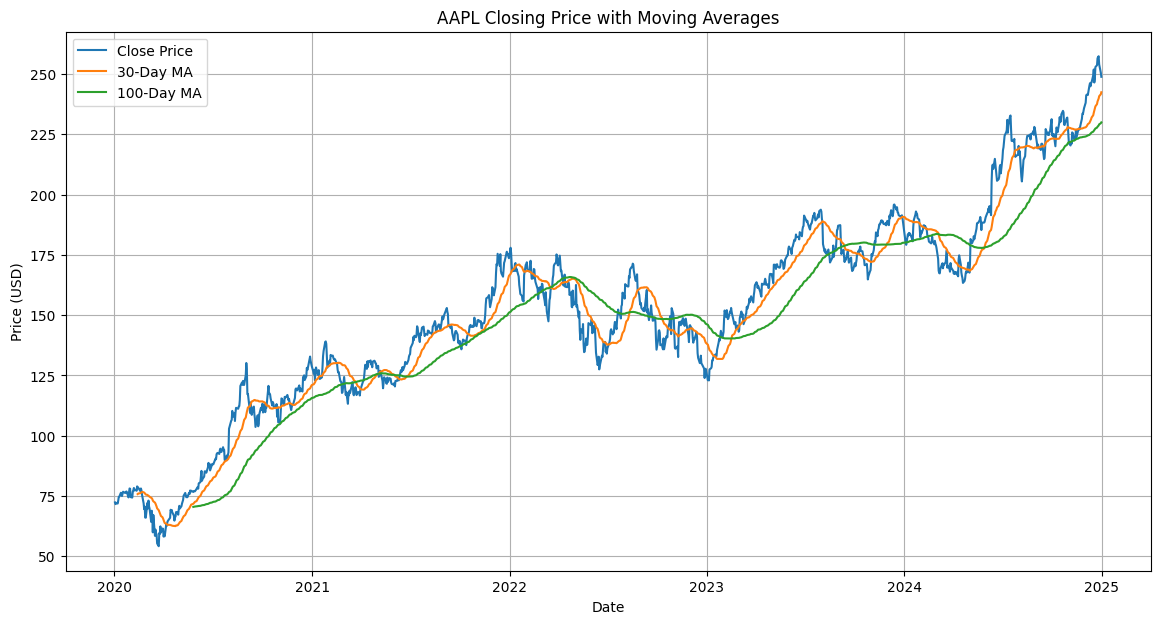

In [7]:
# Create moving averages
df['MA30'] = df['Close'].rolling(window=30).mean()
df['MA100'] = df['Close'].rolling(window=100).mean()

plt.figure(figsize=(14,7))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['MA30'], label='30-Day MA')
plt.plot(df['MA100'], label='100-Day MA')
plt.title("AAPL Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# Extract year and month
df['Year'] = df.index.year
df['Month'] = df.index.month

# Monthly return = last close of month / first close of month - 1
monthly_returns = df['Close'].resample('ME').last().pct_change()

monthly_returns.head()

Ticker,AAPL
Date,
2020-01-31,NaN
2020-02-29,-0.114701
2020-03-31,-0.069762
2020-04-30,0.155374
2020-05-31,0.085094


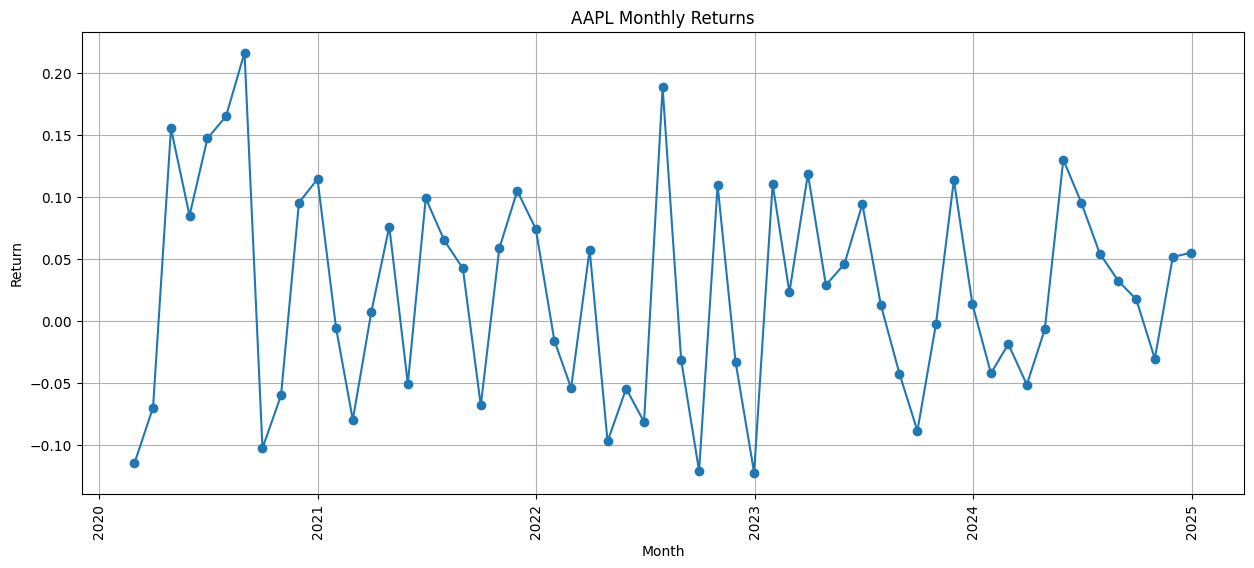

In [9]:
monthly_clean = monthly_returns.dropna()

plt.figure(figsize=(15,6))
plt.plot(monthly_clean.index, monthly_clean.values, marker='o')
plt.title("AAPL Monthly Returns")
plt.xlabel("Month")
plt.ylabel("Return")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

In [10]:
# Key performance numbers
start_price = float(df['Close'].iloc[0])
end_price = float(df['Close'].iloc[-1])
total_return = (end_price / start_price - 1) * 100

years = (df.index[-1] - df.index[0]).days / 365.25
cagr = ((end_price / start_price) ** (1/years) - 1) * 100

# Max drawdown
cumulative_max = df['Close'].cummax()
drawdown = (df['Close'] - cumulative_max) / cumulative_max
max_drawdown = float(drawdown.min()) * 100

# Best/worst month
monthly_series = monthly_clean.squeeze()  # forces it to a plain 1D Series
best_idx = monthly_series.idxmax()
worst_idx = monthly_series.idxmin()

print(f"Total return ({df.index[0].date()} to {df.index[-1].date()}): {total_return:.1f}%")
print(f"CAGR: {cagr:.1f}%")
print(f"Max drawdown: {max_drawdown:.1f}%")
print(f"Best month: {best_idx.date()} ({monthly_series.max()*100:.1f}%)")
print(f"Worst month: {worst_idx.date()} ({monthly_series.min()*100:.1f}%)")

Total return (2020-01-02 to 2024-12-31): 244.0%
CAGR: 28.1%
Max drawdown: -31.4%
Best month: 2020-08-31 (21.7%)
Worst month: 2022-12-31 (-12.2%)


/tmp/ipykernel_7646/336618169.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  start_price = float(df['Close'].iloc[0])
/tmp/ipykernel_7646/336618169.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  end_price = float(df['Close'].iloc[-1])
/tmp/ipykernel_7646/336618169.py:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  max_drawdown = float(drawdown.min()) * 100


📌 1. Closing Price Trend Analysis

From 2020 to 2025, Apple’s stock shows a strong long-term upward trend:


*   The price increased from around \$70 to over $250, nearly tripling.
*  There are multiple short-term dips (e.g., mid-2020, mid-2022, mid-2023), but each decline was followed by a recovery.
*   The trend shows higher highs and higher lows, indicating sustained growth momentum.

**Conclusion:** AAPL shows consistent long-term appreciation with periodic corrections.





📌 2. Daily Returns Distribution

The distribution of daily returns has the following characteristics:
*   Daily volatility (standard deviation) is 2.00%, which annualizes to roughly 31.7% — typical for a large-cap tech stock.
*   Most returns cluster tightly around 0%, indicating moderate day-to-day stability.
*   There is a clear normal distribution–like shape, typical for large-cap stocks.
*   There are a few extreme negative days (left tail), but they are rare.
*   Positive extreme outliers also exist, though less frequently.

**Conclusion:** AAPL experiences mostly small daily moves, with occasional volatility spikes, and an annualized volatility of ~32%.

📌 3. Moving Average (MA) Trend Analysis

The moving averages give us structure to the trend:
*   The 30-day MA tracks the price closely, capturing short-term sentiment.
*   The 100-day MA is much smoother and shows the overall long-term direction.
*   In most periods, the 30-day MA stays above the 100-day MA → bullish trend.
*   When the price dips below the 100-day MA (like mid-2022), these periods correspond to broader corrections.

**Conclusion:** Long-term momentum for AAPL is consistently positive, with smoother growth shown in the 100-day MA.

📌 4. Monthly Returns Analysis

The monthly returns chart shows:


*   Very high month-to-month volatility (some months above +20%, some below –10%).
*   Positive and negative months alternate frequently, but positive months dominate.
*   Largest positive monthly spikes occur around:
    *  Late 2020
    *  Mid 2022
    *  Late 2023

*   Harsh negative months appear around:
    *   2020 pandemic dip
    *  Mid 2022 selloff

*   It shows no simple repeating seasonal pattern, but major market events cause large swings.

**Conclusion:** Monthly returns are inconsistent but lean positive overall, supporting long-term growth.

📌 Final Summary:
> Apple's stock delivered a total return of 244.0% from 2020 to 2024, equivalent to a CAGR of 28.1%. Daily returns are centered around zero, with an annualized volatility of approximately 31.7%. The stock experienced a maximum drawdown of -31.4%, with its worst month being December 2022 (-12.2%) and its best month being August 2020 (+21.7%). Moving average trends confirm sustained upward momentum despite periodic corrections. Overall, AAPL demonstrated strong long-term growth with meaningful but manageable short-term volatility.